In [1]:
import os

import matplotlib.pyplot as plt

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["JAX_ENABLE_X64"] = "true"

import numpy as onp
import numpy.typing as npt
import jax
import jax.numpy as jnp
from tqdm import tqdm
from typing import List, Callable

from gridops import set_up_grid_axis
from gridops import create_anterpolation_function, make_restriction_operator, \
    make_prolongation_operator

import sys

sys.path.append("/home/florian/PhD/work/code/msm_for_nn/")

from msmfornn.splines.nesting import compute_J_zeroplus


In [2]:
p = 8
order = p - 1

# Grid charge computation

In [3]:
length = 10.
h = 0.25
n_particles = 25

grid = set_up_grid_axis(length=length, h=h, p=p, periodic=False)

anterpolate = create_anterpolation_function(grid)
jitted_anterpolate = jax.jit(anterpolate)

In [4]:
rng = onp.random.default_rng(12345)
for _ in tqdm(range(100)):
    positions = jnp.array(rng.uniform(0.0, length, size=n_particles))
    charges = jnp.array(rng.uniform(-1., 1., size=n_particles))

    # Call to trigger compilation
    gridcharge, _, _ = jitted_anterpolate(positions, charges)
    # Second call
    gridcharge, _, _ = jitted_anterpolate(positions, charges)

    assert jnp.allclose(gridcharge.sum(), charges.sum())

100%|██████████| 100/100 [00:01<00:00, 88.23it/s]


In [5]:
gridcharge

Array([ 0.00000000e+00, -2.04670608e-05, -3.10351064e-03, -2.96435732e-02,
        2.57545218e-02,  3.19307347e-01,  2.97496163e-01,  5.79356643e-02,
        1.71659261e-02,  1.18935048e-01,  1.94656818e-01,  7.86104173e-02,
        6.30726612e-02,  3.07328489e-01,  3.14612626e-01, -1.66767980e-01,
       -2.63222969e-01, -1.19418621e-01, -1.10316386e-01, -1.84144971e-01,
       -3.18815469e-01, -2.47155451e-01, -7.47207786e-02, -2.53071960e-02,
       -9.16424842e-03, -4.85031257e-02, -1.75834343e-01, -1.52250766e-01,
       -3.04550041e-02, -1.13605046e-02, -1.06360302e-01, -3.78961309e-01,
       -3.92896456e-01,  1.45688948e-02,  1.30444450e-01, -2.04468504e-01,
       -4.86606264e-01, -2.28954903e-01, -2.06974605e-02,  3.04348576e-02,
        1.63567942e-01,  2.41938745e-01,  3.44332475e-01,  4.47383716e-01,
        1.87469643e-01,  1.87234055e-02,  2.34044692e-04,  7.34110881e-10,
        0.00000000e+00], dtype=float64)

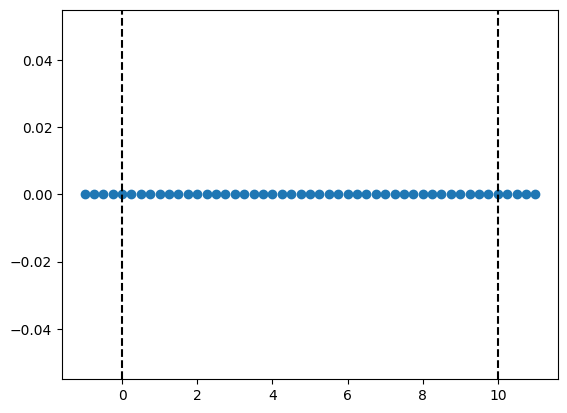

In [6]:
points = (onp.arange(grid.n_total) - p // 2) * grid.h

fig, ax = plt.subplots()
ax.axvline(0, color='k', linestyle='--')
ax.axvline(length, color='k', linestyle='--')
ax.scatter(points, onp.zeros_like(points))


In [7]:
# TODO: compute grid charge for a particle very close to upper domain bound -> I think the grid is currently too small in that case!

pos_appended = jnp.concatenate([positions, jnp.array([10.])])
charges_appended = jnp.concatenate([charges, jnp.array([0.6])])
gc, _, _ = anterpolate(pos_appended, charges_appended)

assert jnp.allclose(gc.sum(), charges_appended.sum())

In [8]:
gc = grid.get_gridindices_and_splinevals(jnp.array([10.]))
gc

(Array([40, 41, 42, 43, 44, 45, 46, 47], dtype=int64),
 Array([0.00000000e+00, 1.98412698e-04, 2.38095238e-02, 2.36309524e-01,
        4.79365079e-01, 2.36309524e-01, 2.38095238e-02, 1.98412698e-04],      dtype=float64))

In [9]:
gc = grid.get_gridindices_and_splinevals(jnp.array([10. - 1.e-6]))
gc

(Array([40, 41, 42, 43, 44, 45, 46, 47], dtype=int64),
 Array([3.25079363e-42, 1.98418254e-04, 2.38098349e-02, 2.36310885e-01,
        4.79365079e-01, 2.36308163e-01, 2.38092127e-02, 1.98407143e-04],      dtype=float64))

In [10]:
int(onp.ceil(length / h))

40

In [11]:
grid.n_domain

41

In [12]:
grid.length, grid.h

(10.0, 0.25)

# Construction of grids

In [13]:
length = 10.0
max_gridlevel = 4

grids_all_levels = [None]  # there is no grid at level zero
for l in range(1, max_gridlevel + 1):
    h = length / (2 ** (max_gridlevel - l))
    print(l, h)
    grid = set_up_grid_axis(length=length, h=h, p=p, periodic=False)
    grids_all_levels.append(grid)

1 1.25
2 2.5
3 5.0
4 10.0


In [14]:
grids_all_levels

[None,
 GridAxis1D(periodic=False, length=10.0, h=1.25, n_domain=9, n_total=17, process_raw_indices=<function set_up_grid_axis.<locals>.process_raw_indices_nonperiodic at 0x7ff52d49c280>, get_gridindices_and_splinevals=<function set_up_grid_axis.<locals>.get_gridindices_and_splinevals at 0x7ff52d49ca60>),
 GridAxis1D(periodic=False, length=10.0, h=2.5, n_domain=5, n_total=13, process_raw_indices=<function set_up_grid_axis.<locals>.process_raw_indices_nonperiodic at 0x7ff52d49c790>, get_gridindices_and_splinevals=<function set_up_grid_axis.<locals>.get_gridindices_and_splinevals at 0x7ff52d49caf0>),
 GridAxis1D(periodic=False, length=10.0, h=5.0, n_domain=3, n_total=11, process_raw_indices=<function set_up_grid_axis.<locals>.process_raw_indices_nonperiodic at 0x7ff52d49c4c0>, get_gridindices_and_splinevals=<function set_up_grid_axis.<locals>.get_gridindices_and_splinevals at 0x7ff52d49c9d0>),
 GridAxis1D(periodic=False, length=10.0, h=10.0, n_domain=2, n_total=10, process_raw_indices=<f

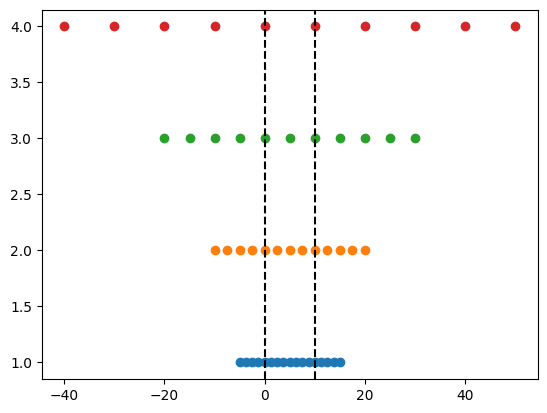

In [15]:
points_all_levels = [None]

fig, ax = plt.subplots()
ax.axvline(0, color='k', linestyle='--')
ax.axvline(length, color='k', linestyle='--')

for l, g in enumerate(grids_all_levels):
    if l == 0:
        continue
    points = (onp.arange(g.n_total) - p // 2) * g.h
    points_all_levels.append(points)
    ax.scatter(points, onp.zeros_like(points) + l)


In [16]:
def shift(m: npt.ArrayLike):
    return m - p // 2


def unshift(m: int):
    return m + p // 2

In [17]:
m_raw = 2
n_raw = shift(onp.arange(len(points_all_levels[1])))

In [18]:
n_raw

array([-4, -3, -2, -1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])

In [19]:
onp.abs(n_raw - 2 * m_raw)

array([8, 7, 6, 5, 4, 3, 2, 1, 0, 1, 2, 3, 4, 5, 6, 7, 8])

In [20]:
onp.abs(n_raw - 2 * m_raw) <= p // 2

array([False, False, False, False,  True,  True,  True,  True,  True,
        True,  True,  True,  True, False, False, False, False])

In [21]:
onp.where(onp.abs(n_raw - 2 * m_raw) <= p // 2)[0]

array([ 4,  5,  6,  7,  8,  9, 10, 11, 12])

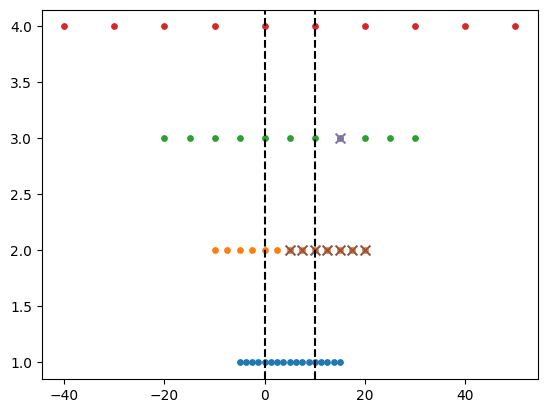

In [22]:
fig, ax = plt.subplots()
ax.axvline(0, color='k', linestyle='--')
ax.axvline(length, color='k', linestyle='--')

for l in range(1, max_gridlevel + 1):
    g = grids_all_levels[l]
    points = points_all_levels[l]
    ax.scatter(points, onp.full_like(points, l), s=15)

l = 3
m_raw = 3
n_raw = shift(onp.arange(len(points_all_levels[l - 1])))
is_in_bounds = onp.where(onp.abs(n_raw - 2 * m_raw) <= p // 2)
n_raw_selected = n_raw[is_in_bounds]

ax.scatter(points_all_levels[l][unshift(m_raw)], l, marker="x", s=50)
ax.scatter(points_all_levels[l - 1][unshift(n_raw_selected)],
           onp.full_like(n_raw_selected, l - 1), marker="x", s=50)

# Restriction

In [23]:
J_zeroplus = compute_J_zeroplus(p)
J = onp.concatenate((J_zeroplus[::-1][:-1], J_zeroplus))
J

array([0.0078125, 0.0625   , 0.21875  , 0.4375   , 0.546875 , 0.4375   ,
       0.21875  , 0.0625   , 0.0078125])

In [24]:
n_particles = 15

rng = onp.random.default_rng(8439293)
xs = rng.uniform(0., length, size=n_particles)
qs = rng.uniform(-1., 1., size=n_particles)

## Compare grid charges computed via restriction with directly computed ones

In [25]:
anterpolation_funcs_all_levels = [None] + [
    jax.jit(create_anterpolation_function(g)) for g in grids_all_levels[1:]]

restriction_funcs_all_levels = [None, None]
for l in range(2, len(grids_all_levels)):
    rf = make_restriction_operator(grid_source=grids_all_levels[l - 1],
                                   grid_target=grids_all_levels[l], J=J)
    rf = jax.jit(rf)
    restriction_funcs_all_levels.append(rf)

In [26]:
gridcharges_direct = [None] + [af(xs, qs)[0] for af in
                               anterpolation_funcs_all_levels[1:]]

gridcharges_via_restriction = [None, None]
for l in range(2, len(grids_all_levels)):
    rf = restriction_funcs_all_levels[l]
    gc_lowergrid = gridcharges_direct[l - 1]
    gc = rf(gc_lowergrid)
    gridcharges_via_restriction.append(gc)

In [27]:
gridcharges_direct

[None,
 Array([ 0.00000000e+00,  1.83374696e-04,  2.41852797e-02,  2.85980886e-01,
         9.07023298e-01,  1.17070121e+00,  9.20908606e-01,  5.97616749e-01,
         3.80868871e-02,  4.43103550e-02,  2.97584891e-01, -3.21452569e-01,
        -4.54071334e-01, -1.02526792e-01, -3.79534960e-03, -2.83815915e-06,
         0.00000000e+00], dtype=float64),
 Array([ 0.00000000e+00,  2.00408416e-04,  3.03306813e-02,  4.17197959e-01,
         1.37772613e+00,  1.50716088e+00,  6.24834054e-01, -1.13965096e-02,
        -3.66477996e-01, -1.64026303e-01, -1.07868312e-02, -2.98285537e-05,
         0.00000000e+00], dtype=float64),
 Array([ 0.00000000e+00,  2.49483973e-04,  4.35608731e-02,  5.99655539e-01,
         1.73510539e+00,  1.23328948e+00, -3.78831280e-02, -1.53671433e-01,
        -1.54874226e-02, -8.61364035e-05,  0.00000000e+00], dtype=float64),
 Array([ 0.00000000e+00,  3.55912069e-04,  6.06720723e-02,  7.42619735e-01,
         1.74233135e+00,  8.65595398e-01,  6.61054825e-03, -1.33259849e-0

In [28]:
gridcharges_via_restriction

[None,
 None,
 Array([ 0.00000000e+00,  2.00408416e-04,  3.03306813e-02,  4.17197959e-01,
         1.37772613e+00,  1.50716088e+00,  6.24834054e-01, -1.13965096e-02,
        -3.66477996e-01, -1.64026303e-01, -1.07868312e-02, -2.98285537e-05,
         0.00000000e+00], dtype=float64),
 Array([ 0.00000000e+00,  2.49483973e-04,  4.35608731e-02,  5.99655539e-01,
         1.73510539e+00,  1.23328948e+00, -3.78831280e-02, -1.53671433e-01,
        -1.54874226e-02, -8.61364035e-05,  0.00000000e+00], dtype=float64),
 Array([ 0.00000000e+00,  3.55912069e-04,  6.06720723e-02,  7.42619735e-01,
         1.74233135e+00,  8.65595398e-01,  6.61054825e-03, -1.33259849e-02,
        -1.26379014e-04,  0.00000000e+00], dtype=float64)]

In [29]:
for gc_direct, gc_restrict in zip(gridcharges_direct[2:],
                                  gridcharges_via_restriction[2:]):
    assert jnp.allclose(gc_direct, gc_restrict)

# Test jitting of anterpolation + loop over restriction at all grid levels in single function

In [30]:
def create_anterpolate_and_restrict(grids_all_levels,
                                    J: npt.ArrayLike) -> Callable:
    anterpolate = create_anterpolation_function(grids_all_levels[1])

    restriction_funcs_all_levels = [None, None]
    for lvl in range(2, len(grids_all_levels)):
        rf = make_restriction_operator(grid_source=grids_all_levels[lvl - 1],
                                       grid_target=grids_all_levels[lvl], J=J)
        restriction_funcs_all_levels.append(rf)

    def anterpolate_and_restrict(positions: jax.Array,
                                 charges: jax.Array) -> List:
        gridcharge_level_one, _, _ = anterpolate(positions_1d=positions,
                                                 charges=charges)
        gridcharges_all_levels = [None, gridcharge_level_one]
        for lvl in range(2, len(grids_all_levels)):
            rf = restriction_funcs_all_levels[lvl]
            gc_lowergrid = gridcharges_all_levels[lvl - 1]
            gc = rf(gc_lowergrid)
            gridcharges_all_levels.append(gc)

        return gridcharges_all_levels

    return anterpolate_and_restrict

In [31]:
anterpolate_and_restrict = create_anterpolate_and_restrict(grids_all_levels, J)
jitted_anterpolate_and_restrict = jax.jit(anterpolate_and_restrict)

In [32]:
jitted_anterpolate_and_restrict(xs, qs)

[None,
 Array([ 0.00000000e+00,  1.83374696e-04,  2.41852797e-02,  2.85980886e-01,
         9.07023298e-01,  1.17070121e+00,  9.20908606e-01,  5.97616749e-01,
         3.80868871e-02,  4.43103550e-02,  2.97584891e-01, -3.21452569e-01,
        -4.54071334e-01, -1.02526792e-01, -3.79534960e-03, -2.83815915e-06,
         0.00000000e+00], dtype=float64),
 Array([ 0.00000000e+00,  2.00408416e-04,  3.03306813e-02,  4.17197959e-01,
         1.37772613e+00,  1.50716088e+00,  6.24834054e-01, -1.13965096e-02,
        -3.66477996e-01, -1.64026303e-01, -1.07868312e-02, -2.98285537e-05,
         0.00000000e+00], dtype=float64),
 Array([ 0.00000000e+00,  2.49483973e-04,  4.35608731e-02,  5.99655539e-01,
         1.73510539e+00,  1.23328948e+00, -3.78831280e-02, -1.53671433e-01,
        -1.54874226e-02, -8.61364035e-05,  0.00000000e+00], dtype=float64),
 Array([ 0.00000000e+00,  3.55912069e-04,  6.06720723e-02,  7.42619735e-01,
         1.74233135e+00,  8.65595398e-01,  6.61054825e-03, -1.33259849e-0

# Prolongation

In [33]:
J_rolled = onp.roll(J, (len(J) - 1) // 2 + 1)

ns_raw = jnp.arange(-10, 15)

for m_raw in range(0, 10):
    m_minus_2n = m_raw - 2 * ns_raw
    cond = jnp.abs(m_minus_2n) <= p / 2
    inds_into_J = m_minus_2n[cond]
    print(m_raw, cond.sum(), inds_into_J, J_rolled[inds_into_J])

0 5 [ 4  2  0 -2 -4] [0.0078125 0.21875   0.546875  0.21875   0.0078125]
1 4 [ 3  1 -1 -3] [0.0625 0.4375 0.4375 0.0625]
2 5 [ 4  2  0 -2 -4] [0.0078125 0.21875   0.546875  0.21875   0.0078125]
3 4 [ 3  1 -1 -3] [0.0625 0.4375 0.4375 0.0625]
4 5 [ 4  2  0 -2 -4] [0.0078125 0.21875   0.546875  0.21875   0.0078125]
5 4 [ 3  1 -1 -3] [0.0625 0.4375 0.4375 0.0625]
6 5 [ 4  2  0 -2 -4] [0.0078125 0.21875   0.546875  0.21875   0.0078125]
7 4 [ 3  1 -1 -3] [0.0625 0.4375 0.4375 0.0625]
8 5 [ 4  2  0 -2 -4] [0.0078125 0.21875   0.546875  0.21875   0.0078125]
9 4 [ 3  1 -1 -3] [0.0625 0.4375 0.4375 0.0625]


In [34]:
def find_raw_ns_by_ceil_floor(m_raw):
    if m_raw % 2 == 0:
        start = int(onp.ceil(onp.round(-p / 4, decimals=1)))
        end = int(onp.floor(onp.round(p / 4, decimals=1)))
    else:
        start = int(onp.ceil(onp.round(0.5 - p / 4, decimals=1)))
        end = int(onp.floor(onp.round(0.5 + p / 4, decimals=1)))

    return m_raw // 2 + jnp.arange(start, end + 1), start, end

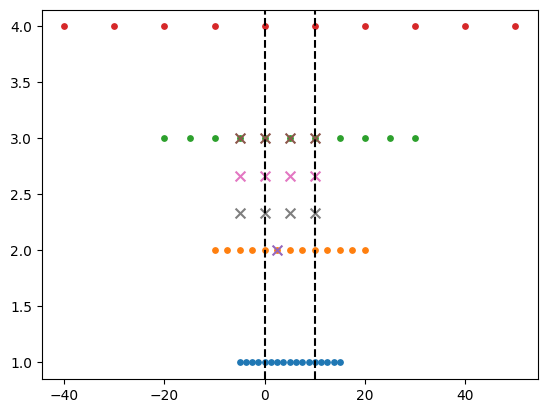

In [35]:
lvl = 2
m_raw = 1

fig, ax = plt.subplots()
ax.axvline(0, color='k', linestyle='--')
ax.axvline(length, color='k', linestyle='--')
for l in range(1, max_gridlevel + 1):
    g = grids_all_levels[l]
    points = points_all_levels[l]
    ax.scatter(points, onp.full_like(points, l), s=15)

ax.scatter(points_all_levels[lvl][unshift(m_raw)], lvl, marker="x", s=50)

# find contributing points by applying comparison
ns_raw = shift(onp.arange(len(points_all_levels[lvl + 1])))
m_minus_2n = m_raw - 2 * ns_raw
cond = jnp.abs(m_minus_2n) <= p // 2
ns_raw_selected = ns_raw[cond]

ax.scatter(points_all_levels[lvl + 1][unshift(ns_raw_selected)],
           onp.full_like(ns_raw_selected, lvl + 1), marker="x", s=50)

# find contributing points by explicit expression
if p % 4 == 0:
    extra = 0
else:
    extra = 1
start = m_raw // 2 - p // 4
end = m_raw // 2 + p // 4
if m_raw % 2 == 0:
    raw_n_range = jnp.arange(start, end + 1)
else:
    raw_n_range = jnp.arange(start + 1 - extra, end + extra + 1)

ax.scatter(points_all_levels[lvl + 1][unshift(raw_n_range)],
           onp.full_like(raw_n_range, lvl + 1 - 0.3333, dtype=float),
           marker="x", s=50)

# find by ceil/floor
raw_ns_by_ceil_floor, start, end = find_raw_ns_by_ceil_floor(m_raw)
ax.scatter(points_all_levels[lvl + 1][unshift(raw_ns_by_ceil_floor)],
           onp.full_like(raw_ns_by_ceil_floor, lvl + 1 - 0.6666, dtype=float),
           marker="x", s=50)

assert onp.array_equal(ns_raw_selected, raw_n_range)
assert onp.array_equal(ns_raw_selected, raw_ns_by_ceil_floor)

# TODO
# m_raw // 2 + jnp.arange(-p // 4, p // 4 + extra + 1)  # or sth like that

In [36]:
lvl = 1

prolongate = make_prolongation_operator(
    grid_source=grids_all_levels[lvl + 1],
    grid_target=grids_all_levels[lvl],
    p=p,
    J_zeroplus=J_zeroplus,
)
jitted_prolongate = jax.jit(prolongate)

In [37]:
prolongate(array_coarse=gridcharges_direct[lvl + 1])

Array([ 0.11865647,  0.28191419,  0.54794382,  0.88137251,  1.17951595,
        1.32726507,  1.26545897,  1.01814339,  0.67680496,  0.33967161,
        0.06077616, -0.13651961, -0.23399415, -0.23348209, -0.17231783,
       -0.09938749, -0.04464944], dtype=float64)

In [38]:
jitted_prolongate(array_coarse=gridcharges_direct[lvl + 1])

Array([ 0.11865647,  0.28191419,  0.54794382,  0.88137251,  1.17951595,
        1.32726507,  1.26545897,  1.01814339,  0.67680496,  0.33967161,
        0.06077616, -0.13651961, -0.23399415, -0.23348209, -0.17231783,
       -0.09938749, -0.04464944], dtype=float64)

## Check against explicit matrix multiplication

In [39]:
def get_entry_of_J(idx):
    if onp.abs(idx) > p // 2:
        return 0.
    else:
        return J_zeroplus[abs(idx)]

In [40]:
I_21 = onp.zeros((grids_all_levels[2].n_total, grids_all_levels[1].n_total))
for m in range(I_21.shape[0]):
    for n in range(I_21.shape[1]):
        m_raw = m - p // 2
        n_raw = n - p // 2
        I_21[m, n] = get_entry_of_J(n_raw - 2 * m_raw)

I_12 = I_21.T

In [41]:
I_21

array([[0.0078125, 0.       , 0.       , 0.       , 0.       , 0.       ,
        0.       , 0.       , 0.       , 0.       , 0.       , 0.       ,
        0.       , 0.       , 0.       , 0.       , 0.       ],
       [0.21875  , 0.0625   , 0.0078125, 0.       , 0.       , 0.       ,
        0.       , 0.       , 0.       , 0.       , 0.       , 0.       ,
        0.       , 0.       , 0.       , 0.       , 0.       ],
       [0.546875 , 0.4375   , 0.21875  , 0.0625   , 0.0078125, 0.       ,
        0.       , 0.       , 0.       , 0.       , 0.       , 0.       ,
        0.       , 0.       , 0.       , 0.       , 0.       ],
       [0.21875  , 0.4375   , 0.546875 , 0.4375   , 0.21875  , 0.0625   ,
        0.0078125, 0.       , 0.       , 0.       , 0.       , 0.       ,
        0.       , 0.       , 0.       , 0.       , 0.       ],
       [0.0078125, 0.0625   , 0.21875  , 0.4375   , 0.546875 , 0.4375   ,
        0.21875  , 0.0625   , 0.0078125, 0.       , 0.       , 0.       ,
    

In [42]:
I_12

array([[0.0078125, 0.21875  , 0.546875 , 0.21875  , 0.0078125, 0.       ,
        0.       , 0.       , 0.       , 0.       , 0.       , 0.       ,
        0.       ],
       [0.       , 0.0625   , 0.4375   , 0.4375   , 0.0625   , 0.       ,
        0.       , 0.       , 0.       , 0.       , 0.       , 0.       ,
        0.       ],
       [0.       , 0.0078125, 0.21875  , 0.546875 , 0.21875  , 0.0078125,
        0.       , 0.       , 0.       , 0.       , 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.0625   , 0.4375   , 0.4375   , 0.0625   ,
        0.       , 0.       , 0.       , 0.       , 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.0078125, 0.21875  , 0.546875 , 0.21875  ,
        0.0078125, 0.       , 0.       , 0.       , 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , 0.0625   , 0.4375   , 0.4375   ,
        0.0625   , 0.       , 0.       , 0.       , 0.       , 0.       ,
        0.  

In [43]:
# Compare restriction operator with explicit matrix multiplication
# (This is arguably redundant for testing the restriction operator, but it shows
# us whether we have correctly set up the I matrix, which we'll use again below)
assert jnp.allclose(I_21 @ gridcharges_direct[1], gridcharges_direct[2])

# Compare prolongation operator with explicit matrix multiplication
assert jnp.allclose(I_12 @ gridcharges_direct[2],
                    prolongate(gridcharges_direct[2]))